In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load Data 
df = pd.read_csv('../dataset/train.csv', encoding='utf-8')

In [3]:
# 'Age' column ki missing values ko uske median (middle value) se fill karein
df['Age'] = df['Age'].fillna(df['Age'].median())

# 'Cabin' column mein bohat zyada (approx 77%) missing values hoti hain, isliye isko drop kar dete hain
df.drop('Cabin', axis=1, inplace=True)

# 'Embarked' mein sirf 2 missing values hain, isko mode (sab se zyada aane wali value) se fill kar dein
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Check karein ke ab koi missing value bachi hai ya nahi
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [10]:
# Clean dataset ko CSV file mein save karna
df.to_csv('cleaned_data.csv', index=False)

I handled missing values using two methods. For the 'Age' column, I used fillna() with the median because it is a numerical feature and median is robust to outliers. For the 'Cabin' column, I used drop() because more than 70% of the data was missing, making it useless for the model. For 'Embarked', I filled the minimal missing rows with the most frequent value (mode).

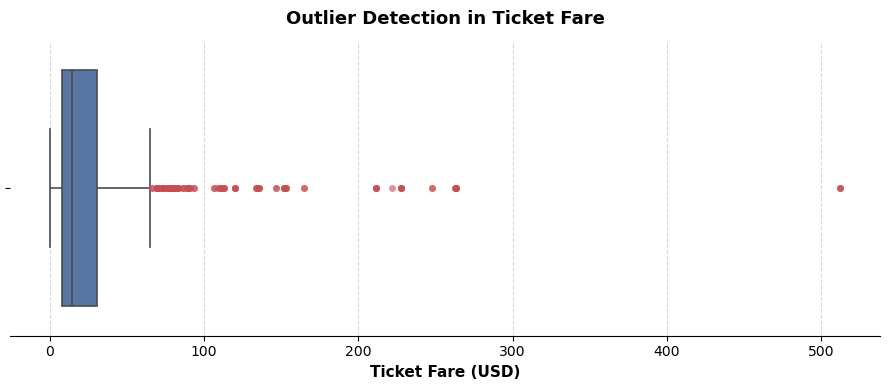

In [4]:
# Fare column mein outliers detect karne ke liye professional boxplot
plt.figure(figsize=(9, 4))
ax = sns.boxplot(
    x=df['Fare'], 
    color='#4c72b0', 
    fliersize=5, 
    linewidth=1.2,
    flierprops={'marker': 'o', 'markerfacecolor': '#c44e52', 'markeredgecolor': 'none', 'alpha': 0.6}
)
plt.title("Outlier Detection in Ticket Fare", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Ticket Fare (USD)", fontsize=11, fontweight='semibold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine(left=True, top=True, right=True)
plt.tight_layout()
plt.show()

In [5]:
# Set professional aesthetic style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

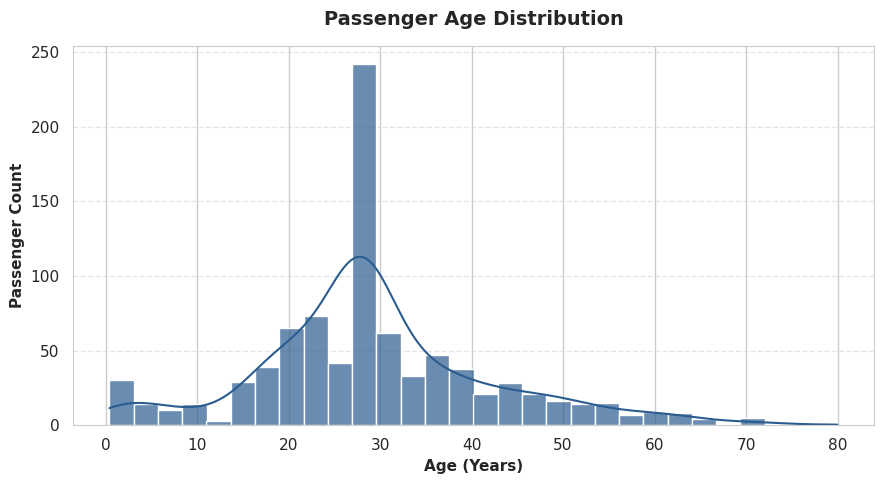

In [6]:
# 1. Histogram: Age Distribution with KDE
plt.figure(figsize=(9, 5))
ax = sns.histplot(df['Age'], kde=True, bins=30, color='#2b5c8f', alpha=0.7)
plt.title('Passenger Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=11, fontweight='semibold')
plt.ylabel('Passenger Count', fontsize=11, fontweight='semibold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

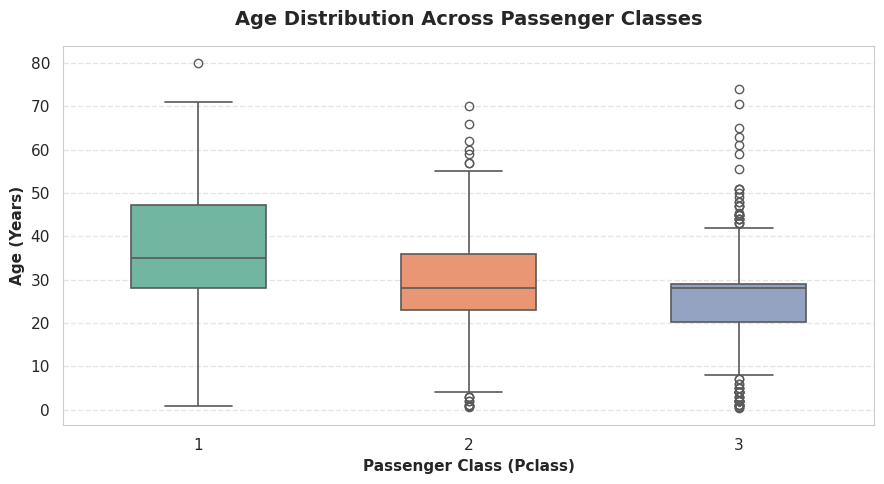

In [7]:
# 2. Boxplot: Age Distribution across Passenger Classes
plt.figure(figsize=(9, 5))
sns.boxplot(x='Pclass', y='Age', hue='Pclass', data=df, palette='Set2', width=0.5, linewidth=1.2, legend=False)
plt.title('Age Distribution Across Passenger Classes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Passenger Class (Pclass)', fontsize=11, fontweight='semibold')
plt.ylabel('Age (Years)', fontsize=11, fontweight='semibold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

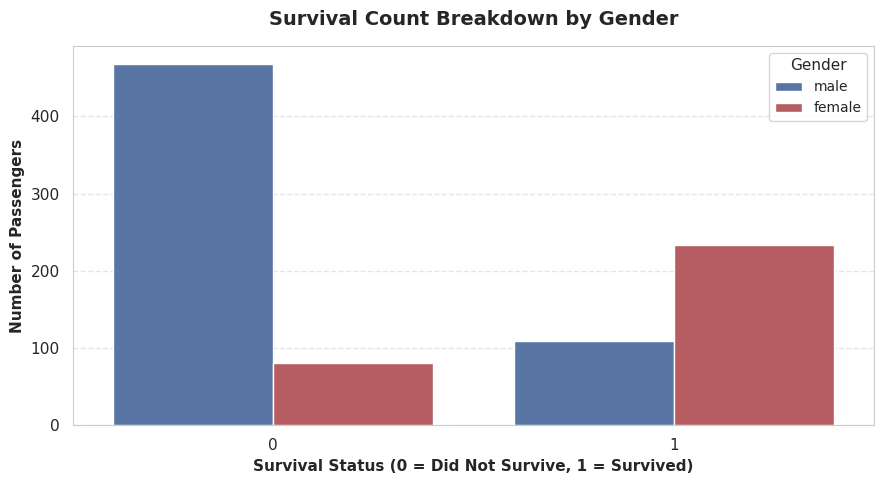

In [8]:
# 3. Bar Chart: Survival Count based on Gender (Professional Countplot)
plt.figure(figsize=(9, 5))
ax = sns.countplot(x='Survived', hue='Sex', data=df, palette=['#4c72b0', '#c44e52'])
plt.title('Survival Count Breakdown by Gender', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)', fontsize=11, fontweight='semibold')
plt.ylabel('Number of Passengers', fontsize=11, fontweight='semibold')
plt.legend(title='Gender', title_fontsize='11', fontsize='10', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

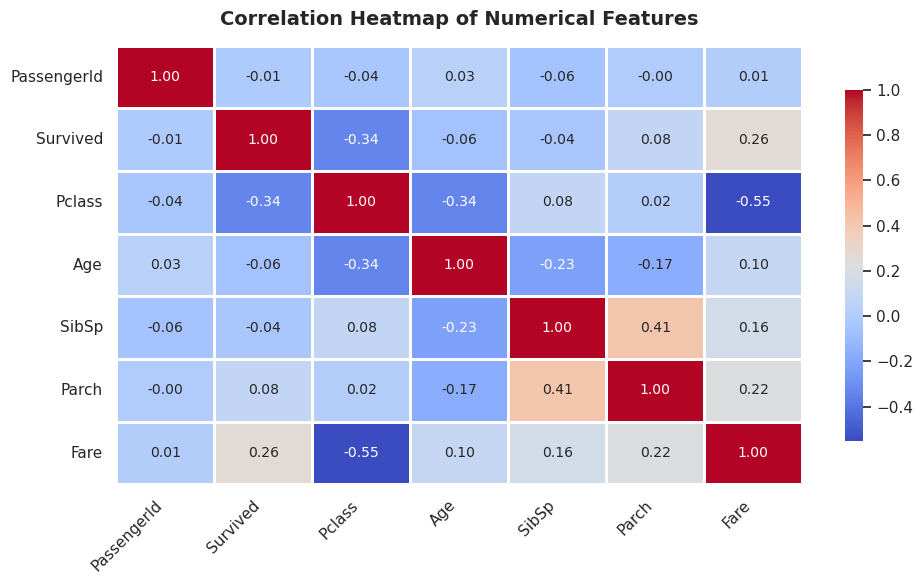

In [9]:
# 4. Correlation Heatmap of Numerical Features
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool)) # Optional: sirf lower triangle dikhane ke liye
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.8, cbar_kws={'shrink': 0.8}, annot_kws={'size': 10})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Which feature do you think most affects survival, and why?

Based on the exploratory data analysis and the visualizations, 'Sex' (Gender) is the most significant feature affecting a passenger's chance of survival.

As clearly visible in the "Survival Count Breakdown by Gender" bar chart, female passengers had a drastically higher survival rate compared to male passengers. This strongly aligns with the historical context of the Titanic disaster, where the "women and children first" protocol was strictly enforced during the loading of lifeboats.

Additionally, 'Pclass' (Passenger Class) also played a crucial role. First-class passengers had a much better survival rate than those in second or third class, likely because their cabins were located closer to the main decks, giving them quicker and prioritized access to the lifeboats.